# Transfer Learning y Fine-Tuning

In [1]:
import json
import time
from io import BytesIO
from urllib.request import Request, urlopen

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torchvision.transforms.functional as F
from PIL import Image
from tqdm import tqdm

import csv
import os
from PIL import Image
from torch.utils.data import DataLoader, Dataset, random_split
from torchvision import transforms

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.cuda.is_available()

False

## Dataset

In [3]:
class FoodDataset(Dataset):
    def __init__(self, csv_path, images_dir, transform=None):
        self.images_dir = images_dir
        self.transform = transform
        with open(csv_path) as f:
            reader = csv.DictReader(f)
            self.samples = [(row["filename"], int(row["class_idx"])) for row in reader]

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        fname, label = self.samples[idx]
        img = Image.open(os.path.join(self.images_dir, fname)).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, label

In [4]:
transform = transforms.Compose([
      transforms.Resize((224, 224)),
      transforms.ToTensor(),
      transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224,
   0.225]),
  ])

In [5]:
dataset = FoodDataset("data/labels.csv", "data/images", transform=transform)

In [6]:
n = len(dataset)
train_size = int(0.8 * n)
val_size   = int(0.1 * n)
test_size  = n - train_size - val_size
train_set, val_set, test_set = random_split(dataset, [train_size, val_size, test_size])

In [7]:
train_loader = DataLoader(train_set, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_set,   batch_size=32, shuffle=False)
test_loader  = DataLoader(test_set,  batch_size=32, shuffle=False)

In [8]:
print(f"Train: {len(train_set)} | Val: {len(val_set)} | Test: {len(test_set)}")
print(f"Classes: {{'bobby': 0, 'empanada': 1, 'horchata': 2, 'not_any': 3}}")

Train: 168 | Val: 21 | Test: 21
Classes: {'bobby': 0, 'empanada': 1, 'horchata': 2, 'not_any': 3}


In [9]:
num_classes = 4

## Pre-trained Models

In [10]:
def get_batch_accuracy(output, y, N):
    pred = output.argmax(dim=1, keepdim=True)
    correct = pred.eq(y.view_as(pred)).sum().item()
    return correct / N

In [11]:
def train(_model, _train_loader, _val_loader, _criterion, _optimizer, _num_epochs, _transforms=None):
    res = {
        'train_loss': [],
        'train_acc': [],
        'val_loss': [],
        'val_acc': [],
    }

    for epoch in range(_num_epochs):
        _model.train()
        train_loss = 0.0
        train_acc = 0.0
        for X_batch, y_batch in _train_loader:
            _optimizer.zero_grad()
            _x = X_batch
            if _transforms is not None:
                _x = _transforms(_x)
            outputs = _model(_x)
            loss = _criterion(outputs, y_batch)
            loss.backward()
            _optimizer.step()
            train_loss += loss.item() * X_batch.size(0)
            train_acc += get_batch_accuracy(outputs, y_batch, len(_train_loader.dataset))

        epoch_train_loss = train_loss / len(_train_loader.dataset)

        _model.eval()
        val_loss = 0.0
        val_acc = 0.0
        with torch.no_grad():
            for X_val, y_val in _val_loader:
                val_outputs = _model(X_val)
                val_loss += _criterion(val_outputs, y_val).item() * X_val.size(0)
                val_acc += get_batch_accuracy(val_outputs, y_val, len(_val_loader.dataset))

        epoch_val_loss = val_loss / len(_val_loader.dataset)

        print(f"Epoch {epoch+1}/{_num_epochs} — "
              f"train_loss: {epoch_train_loss:.4f}  train_acc: {train_acc:.4f}  "
              f"val_loss: {epoch_val_loss:.4f}  val_acc: {val_acc:.4f}")

        res['train_loss'].append(epoch_train_loss)
        res['train_acc'].append(train_acc)
        res['val_loss'].append(epoch_val_loss)
        res['val_acc'].append(val_acc)

    return res

In [12]:
def plot_learning_curves(res, title):
    epochs = range(1, len(res['train_loss']) + 1)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.plot(epochs, res['train_loss'], label='Train')
    ax1.plot(epochs, res['val_loss'],   label='Validation')
    ax1.set_title(f'{title} — Loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend()

    ax2.plot(epochs, res['train_acc'], label='Train')
    ax2.plot(epochs, res['val_acc'],   label='Validation')
    ax2.set_title(f'{title} — Accuracy')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.legend()

    plt.tight_layout()
    plt.show()

### ResNet50

In [13]:
from torchvision.models import resnet50
from torchvision.models import ResNet50_Weights

In [14]:
weights = ResNet50_Weights.DEFAULT
model1 = resnet50(weights=weights)

model1.to(device)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

#### Transfer Learning

In [15]:
# 2. Freeze all parameters
for param in model1.parameters():
    param.requires_grad = False

In [16]:
# 3. Replace the final classifier (ResNet uses model.fc, not model.classifier)
model1.fc = nn.Linear(model1.fc.in_features, num_classes)

In [17]:
optimizer = torch.optim.Adam(model1.fc.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()
num_epochs = 5

In [18]:
res = train(model1, train_loader, val_loader, criterion, optimizer, num_epochs)

Epoch 1/5 — train_loss: 1.1730  train_acc: 0.5357  val_loss: 0.8191  val_acc: 0.7619
Epoch 2/5 — train_loss: 0.8550  train_acc: 0.5833  val_loss: 0.6295  val_acc: 0.7619
Epoch 3/5 — train_loss: 0.6468  train_acc: 0.7024  val_loss: 0.5334  val_acc: 0.8571
Epoch 4/5 — train_loss: 0.4707  train_acc: 0.9226  val_loss: 0.4893  val_acc: 1.0000
Epoch 5/5 — train_loss: 0.3687  train_acc: 0.9821  val_loss: 0.4196  val_acc: 1.0000


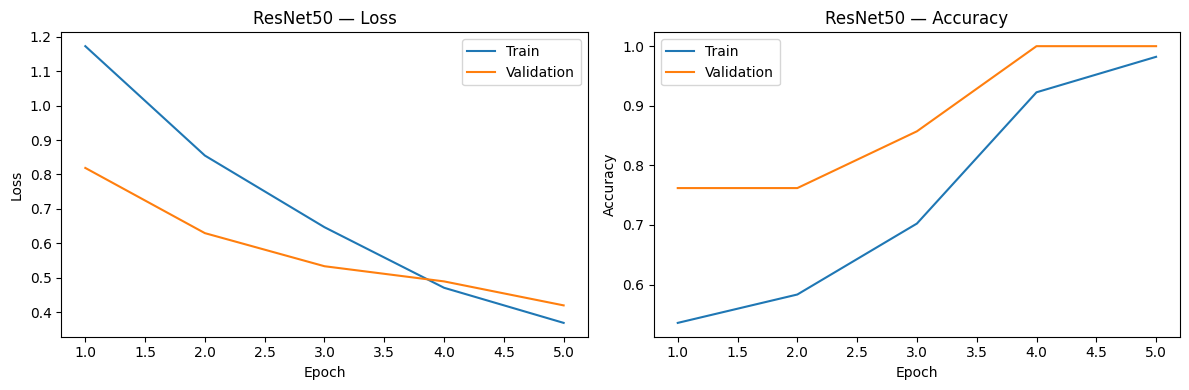

In [19]:
plot_learning_curves(res, title="ResNet50")

#### Fine Tuning

In [20]:
# all
for param in model1.parameters():
    param.requires_grad = False

# layer 4
for param in model1.layer4.parameters():
    param.requires_grad = True

# last layer
for param in model1.fc.parameters():
    param.requires_grad = True


In [21]:
trainable = sum(p.numel() for p in model1.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model1.parameters())
print(f"Trainable params: {trainable:,} / {total:,}")

Trainable params: 14,972,932 / 23,516,228


In [22]:
ft_optimizer = torch.optim.Adam([
    {"params": model1.layer4.parameters(), "lr": 1e-5}, # Pre-trained: low LR
    {"params": model1.fc.parameters(),  "lr": 1e-3}, # New head: normal LR
])
ft_num_epochs = 5

In [23]:
res_ft = train(model1, train_loader, val_loader, criterion, ft_optimizer, ft_num_epochs)

Epoch 1/5 — train_loss: 0.3349  train_acc: 0.9643  val_loss: 0.2835  val_acc: 1.0000
Epoch 2/5 — train_loss: 0.1892  train_acc: 0.9940  val_loss: 0.2240  val_acc: 1.0000
Epoch 3/5 — train_loss: 0.1353  train_acc: 1.0000  val_loss: 0.1857  val_acc: 1.0000
Epoch 4/5 — train_loss: 0.0886  train_acc: 1.0000  val_loss: 0.1399  val_acc: 1.0000
Epoch 5/5 — train_loss: 0.0779  train_acc: 0.9940  val_loss: 0.1182  val_acc: 1.0000


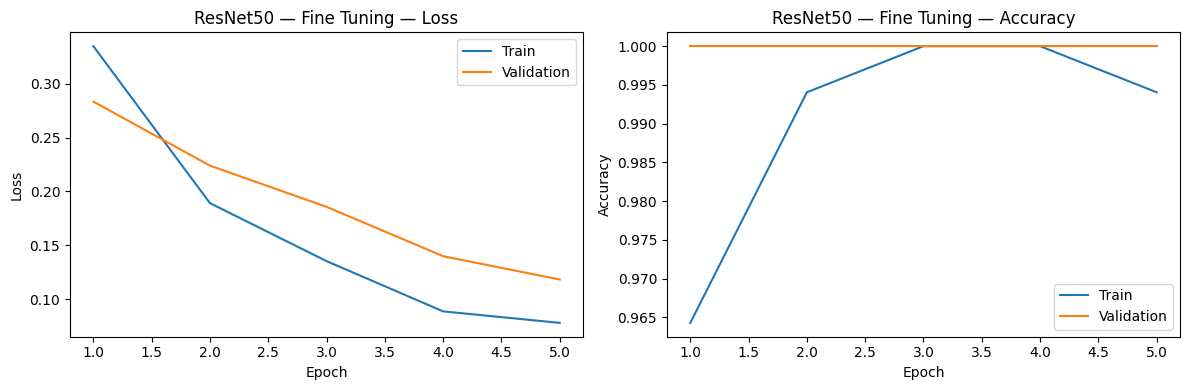

In [24]:
plot_learning_curves(res_ft, title="ResNet50 — Fine Tuning")

### EfficientNet

In [25]:
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights


weights = EfficientNet_B0_Weights.DEFAULT
model2 = efficientnet_b0(weights=weights)    

model2.to(device)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to C:\Users\renat/.cache\torch\hub\checkpoints\efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:01<00:00, 11.8MB/s]


EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

#### Transfer Learning

In [ ]:
for param in model2.parameters():
    param.requires_grad = False

In [26]:
model2.classifier[-1] = nn.Linear(model2.classifier[-1].in_features, num_classes)

In [27]:
optimizer = torch.optim.Adam(model2.classifier.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()
num_epochs = 5

In [28]:
res = train(model2, train_loader, val_loader, criterion, optimizer, num_epochs)

Epoch 1/5 — train_loss: 1.3081  train_acc: 0.4286  val_loss: 0.9308  val_acc: 0.8095
Epoch 2/5 — train_loss: 0.9798  train_acc: 0.6250  val_loss: 0.7400  val_acc: 0.7619
Epoch 3/5 — train_loss: 0.8304  train_acc: 0.6488  val_loss: 0.6390  val_acc: 0.8095
Epoch 4/5 — train_loss: 0.6609  train_acc: 0.7738  val_loss: 0.5839  val_acc: 0.9048
Epoch 5/5 — train_loss: 0.5639  train_acc: 0.9107  val_loss: 0.5279  val_acc: 0.9048


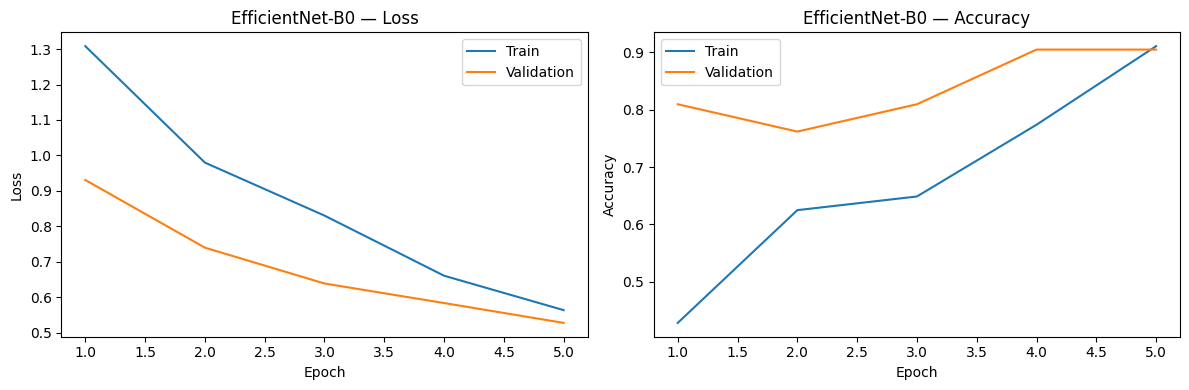

In [29]:
plot_learning_curves(res, title="EfficientNet-B0")

#### Fine Tuning

In [31]:
for param in model2.parameters():
    param.requires_grad = False

# Unfreeze the last few layers of the feature extractor 
for param in model2.features[7:].parameters():
    param.requires_grad = True

# Unfreeze the classifier head
for param in model2.classifier.parameters():
    param.requires_grad = True

In [33]:
ft_optimizer = torch.optim.Adam([
    {"params": model2.features[7:].parameters(), "lr": 1e-5}, # Pre-trained: low LR
    {"params": model2.classifier.parameters(), "lr": 1e-3}, # New head: normal LR   
])

In [34]:
ft_num_epochs = 5

In [37]:
res_ft = train(model2, train_loader, val_loader, criterion, ft_optimizer, ft_num_epochs)

Epoch 1/5 — train_loss: 0.1753  train_acc: 0.9821  val_loss: 0.2503  val_acc: 0.9524
Epoch 2/5 — train_loss: 0.1174  train_acc: 0.9940  val_loss: 0.1957  val_acc: 0.9524
Epoch 3/5 — train_loss: 0.1174  train_acc: 0.9821  val_loss: 0.1728  val_acc: 0.9524
Epoch 4/5 — train_loss: 0.1006  train_acc: 0.9881  val_loss: 0.1675  val_acc: 0.9524
Epoch 5/5 — train_loss: 0.0865  train_acc: 0.9940  val_loss: 0.1627  val_acc: 0.9524


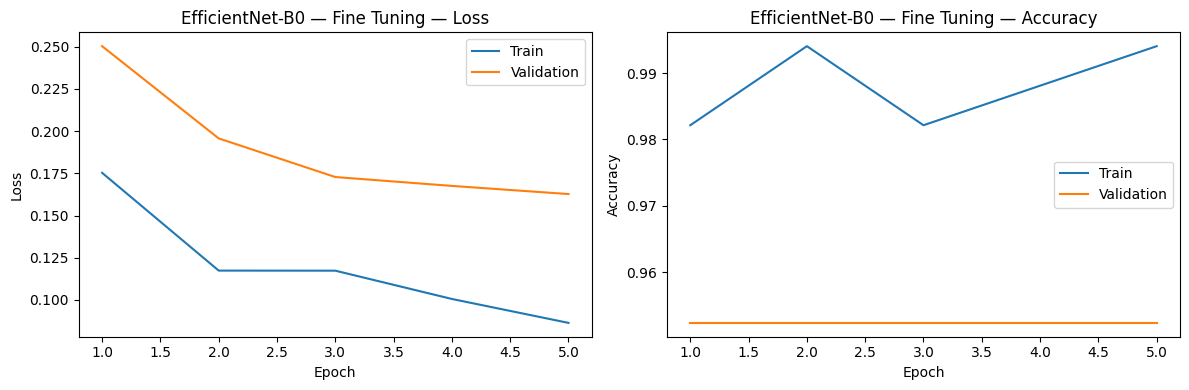

In [38]:
plot_learning_curves(res_ft, title="EfficientNet-B0 — Fine Tuning")